## Homework 5: Transfer Learning with MobileNetV2 on the Intel Image Dataset

**Due: Sunday, October 4, 2026, at 11:59 PM ET**

There is a grace period until **2:00 AM ET**. After that, late submissions are penalized **10% for each 24-hour period**. After **5 days**, the score is 0.

In this assignment, you will use a modern pretrained CNN, **MobileNetV2**, to classify the **Intel Image Dataset**, which contains 6 scene classes.

You will begin by using MobileNetV2 as a **frozen feature extractor**, training only a new classification head. You will then explore progressively more flexible transfer-learning strategies by making all or part of the pretrained backbone trainable.

To make experimentation practical, the notebook provides a `DATA_FRACTION` setting. During development, you may use a smaller fraction of the dataset to test ideas and compare configurations more quickly. Before recording your final results, set:

```python
DATA_FRACTION = 1.0
```

and rerun the complete notebook using the full dataset.

Because MobileNetV2 was pretrained on ImageNet, the images are processed using `mobilenet_v2.preprocess_input`, which scales the input pixels to the range expected by the pretrained network.

The goal is to understand **why transfer learning works**, how to design a useful **classification head**, and how choices such as **learning rate**, **learning-rate control with `ReduceLROnPlateau`**, **regularization**, and **which pretrained layers are allowed to change** affect model performance.

### Learning Objectives

By the end of this homework, you should be able to:

* Use a pretrained CNN as a **frozen feature extractor**.
* Design and compare different **classification heads** on top of a pretrained backbone.
* Experiment efficiently using a reduced dataset before running final models on the full dataset.
* Understand the difference between a **frozen backbone** and making some or all pretrained layers trainable.
* Use practical training controls including:

  * fixed **learning rates**,
  * `ReduceLROnPlateau`,
  * `EarlyStopping`,
  * **Dropout** and **L2 regularization**,
  * and **Batch Normalization** in classification heads.
* Compare strategies that make:

  * the **entire backbone** trainable,
  * only the **last N layers** trainable,
  * or only the **top K MobileNetV2 blocks** trainable.

### Baseline Model

The starting backbone is:

```python
MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

With `pooling="avg"`, MobileNetV2 already applies **Global Average Pooling** and outputs a **1280-dimensional feature vector** for each image.

The baseline classification head consists of a single:

```python
Dense(num_classes, activation="softmax")
```

layer for the 6 Intel classes.

**Do not add another pooling layer when `pooling="avg"` is used.**

### The Five Problems

1. **Problem 1 — Frozen Backbone:**
   Keep MobileNetV2 frozen and redesign only the **classification head**. Try at least three head designs and experiment with training hyperparameters.

2. **Problem 2 — Fully Trainable Backbone:**
   Use one of your best head architectures from Problem 1, make the **entire MobileNetV2 backbone trainable**, and experiment with appropriately small learning rates and other training choices.

3. **Problem 3 — Unfreeze the Last N Layers:**
   Keep most of MobileNetV2 frozen while allowing only the **last N layers** to be updated.

4. **Problem 4 — Unfreeze the Top K Blocks:**
   Instead of selecting individual layers, make only the **top K MobileNetV2 blocks or stages** trainable and compare the results.

5. **Problem 5 -- Final Reflection**

Use your **HW4 CNN results as a reference point**. Transfer learning may or may not outperform every model you developed in HW4; the important goal is to understand how the different transfer-learning strategies affect training behavior and model performance.



## 1. Setup and Data Loading


In [1]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=64,  # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping=True,
                   patience=8,
                   min_delta=1e-4,
                   callbacks=None,
                   verbose=1,
                   return_history=False):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc   = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 1.0

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 -> MobileNetV2 preprocessing
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


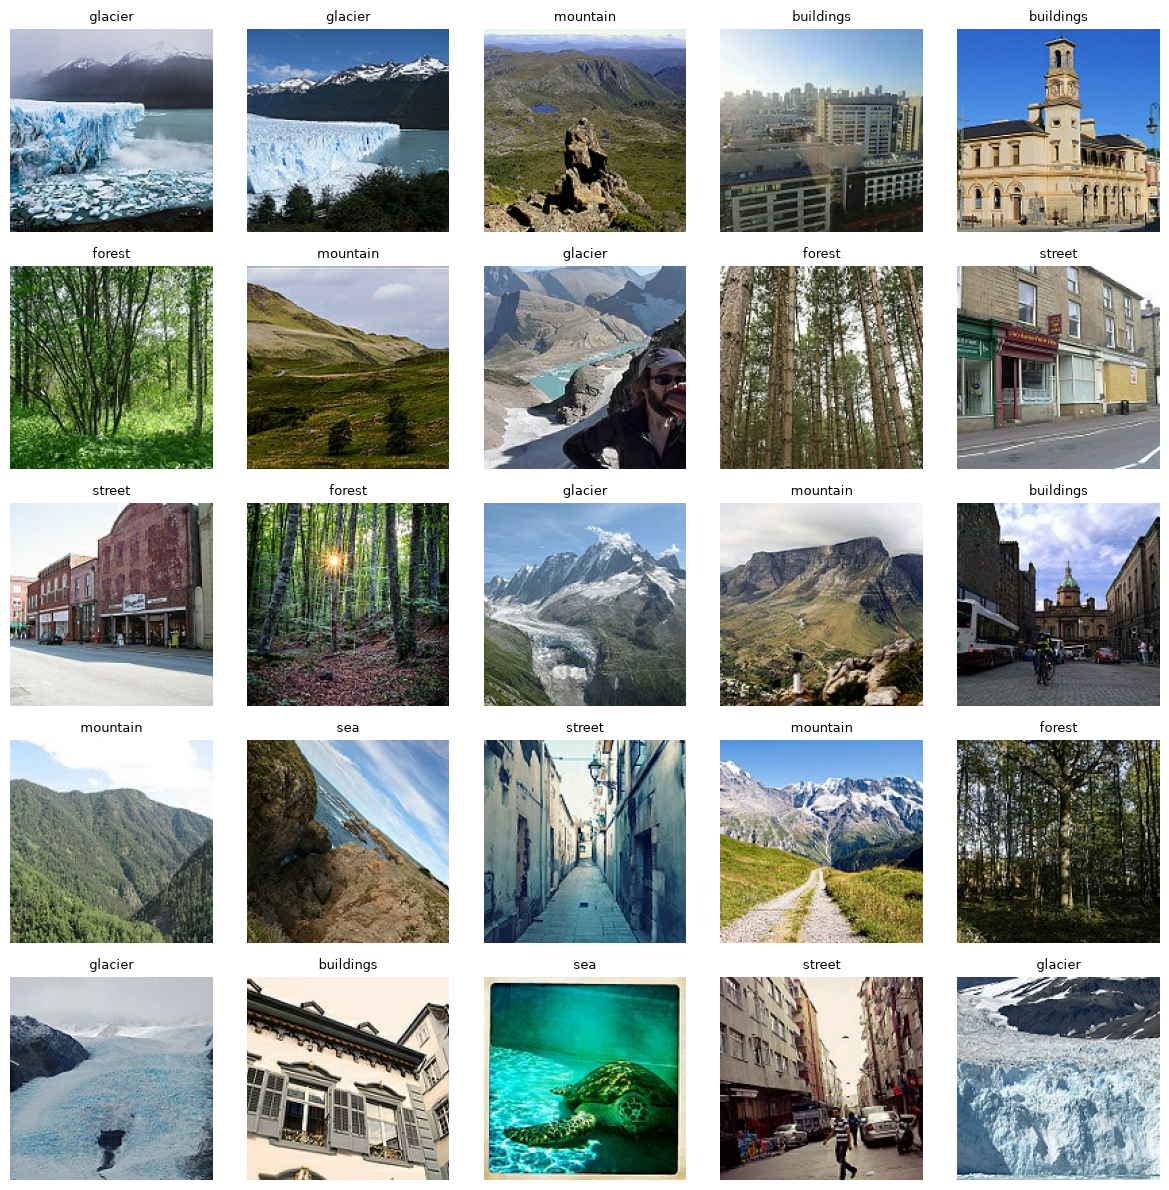

In [7]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)

    # Convert MobileNetV2 [-1, 1] values back to [0, 1] for display
    img = (images[i].numpy() + 1.0) / 2.0

    plt.imshow(img)
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Learning Rate Schedulers

In [8]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

### Prelude: Baseline Model

`MobileNetV2` is a lightweight CNN pretrained on the ImageNet dataset. We will use it as a source of high-quality visual features rather than training a convolutional network from scratch.

See the **Appendix** for additional information about `MobileNetV2`.

The baseline model defined below uses `MobileNetV2` as a frozen **feature extractor**. With `include_top=False` and built-in **Global Average Pooling**, the backbone produces a 1280-dimensional feature vector for each image.

The images have already been processed using `mobilenet_v2.preprocess_input`, which scales the pixel values to the range expected by the pretrained MobileNetV2 weights.

> **NOTE:** The standard MobileNetV2 ImageNet weights are associated with 224×224 images. We use 150×150 images to reduce training time. This is valid because, with `include_top=False`, the convolutional backbone can operate on different input image sizes.
>
> Keras may therefore issue a warning such as:
>
> `UserWarning: input_shape is undefined or non-square, ...`
>
> You may safely ignore this warning for this assignment.


In [9]:
# ALWAYS construct a new instance to avoid sharing layers across models.

def make_base_model_pooled(trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
        pooling="avg",
    )
    base.trainable = trainable
    return base


base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({
    int(layer.name.split("_")[1])
    for layer in base.layers
    if layer.name.startswith("block_")
})
print("Conv Block IDs:", block_ids, "(count:", len(block_ids), ")")

# Check whether the final Conv_1 stage exists
has_conv1 = any(
    layer.name.startswith("Conv_1")
    for layer in base.layers
)

print("Has Conv_1 stage:", has_conv1)
print("Model Output Shape:", base.output_shape)

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [10]:
# Ha, this is very long!

base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Model Baseline

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.8598 - loss: 0.3854 - val_accuracy: 0.8891 - val_loss: 0.2995
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9102 - loss: 0.2484 - val_accuracy: 0.8991 - val_loss: 0.2758
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9209 - loss: 0.2142 - val_accuracy: 0.8919 - val_loss: 0.2996
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9292 - loss: 0.1938 - val_accuracy: 0.9012 - val_loss: 0.2793
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9349 - loss: 0.1765 - val_accuracy: 0.8791 - val_loss: 0.3571
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9379 - loss: 0.1655 - val_accuracy: 0.8969 - val_loss: 0.3018
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9417 - loss: 0.1542 - val_accuracy: 0.8916 - val_loss: 0.3050
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9459 - loss: 0.1444 - val_

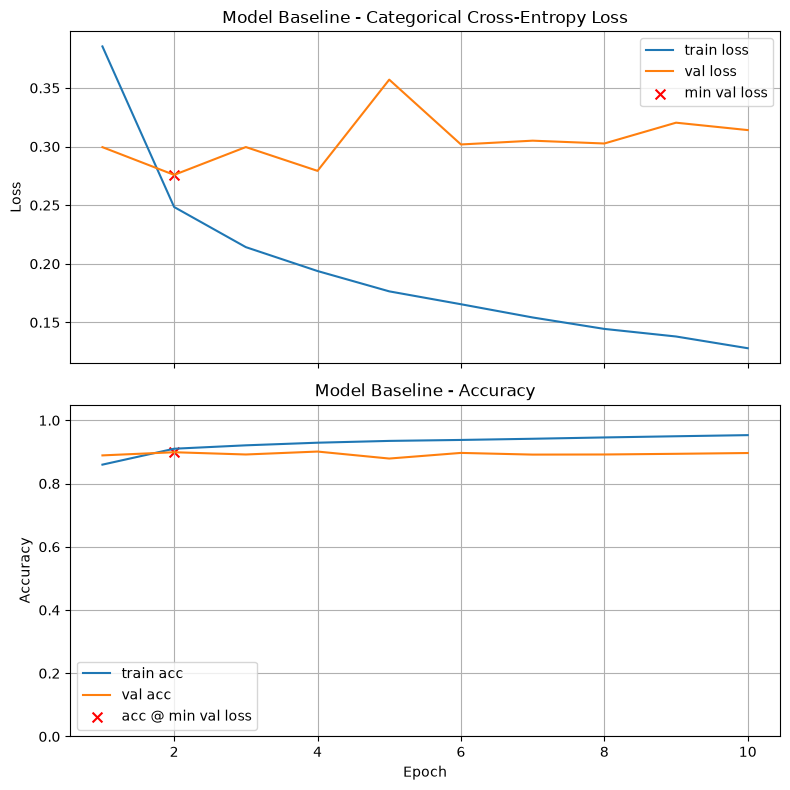

Final Training Loss:            0.1280
Final Training Accuracy:        0.9532
Final Validation Loss:          0.3141
Final Validation Accuracy:      0.8966
Minimum Validation Loss:        0.2758 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8991

Test Loss: 0.2627
Test Accuracy: 0.9023

Validation-Test Gap (accuracy): 0.003261

Execution Time: 00:02:00


In [11]:
# Construct a fresh frozen MobileNetV2 backbone

base_model = make_base_model_pooled()

model_baseline = models.Sequential([
    base_model,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_baseline, title="Model Baseline")

### Problem 1 — Frozen MobileNetV2 (Feature Extractor): Redesign the Head

**Goal.** Keep the MobileNetV2 backbone **frozen** and try to improve accuracy by modifying **only the classification head**.

**Setup.**

```python
base = make_base_model_pooled(
    trainable=False
)  # MobileNetV2(include_top=False, pooling="avg")
```

This backbone already applies **Global Average Pooling** and outputs a **1280-D feature vector** for each image.

Do **not** unfreeze any backbone layers, and do **not** add another pooling layer.

### To Do

1. **Ask an AI helper** (e.g., ChatGPT):

   *“What are some more complex classification heads that could improve this model on the Intel Image Classification Dataset, without unfreezing the MobileNetV2 backbone?”*

2. **Implement at least three different head designs.** These may be AI-suggested or inspired by techniques used in HW4.

3. **Experiment with hyperparameters** for the different designs, such as:

   * learning rate
   * `EarlyStopping` settings
   * Dropout and/or L2 regularization
   * `ReduceLROnPlateau` on or off

4. **Train and compare** the three head designs using a reduced value of `DATA_FRACTION`.

   Use these runs to compare architectures and training behavior and to narrow down a reasonable final configuration.

5. **Select one configuration**, set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this full-data run when answering the graded questions.

6. **Answer the graded questions.**

### Notes / Constraints

* With `pooling="avg"`, the backbone output has shape **(None, 1280)**, so **do not add `GlobalAveragePooling2D()`** to the head.
* `BatchNormalization` may be used within the classification head.
* Keep the entire MobileNetV2 backbone frozen for all experiments in this problem.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8719 - loss: 0.4118 - val_accuracy: 0.8980 - val_loss: 0.3231 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9174 - loss: 0.2833 - val_accuracy: 0.9051 - val_loss: 0.3125 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9312 - loss: 0.2407 - val_accuracy: 0.9119 - val_loss: 0.3233 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9404 - loss: 0.2191 - val_accuracy: 0.8930 - val_loss: 0.3545 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9467 - loss: 0.2049
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9467 - loss: 0.2049 - val_accuracy: 0.8930 - val_loss: 0.3747 - learning_rate: 0.0010
Epoch

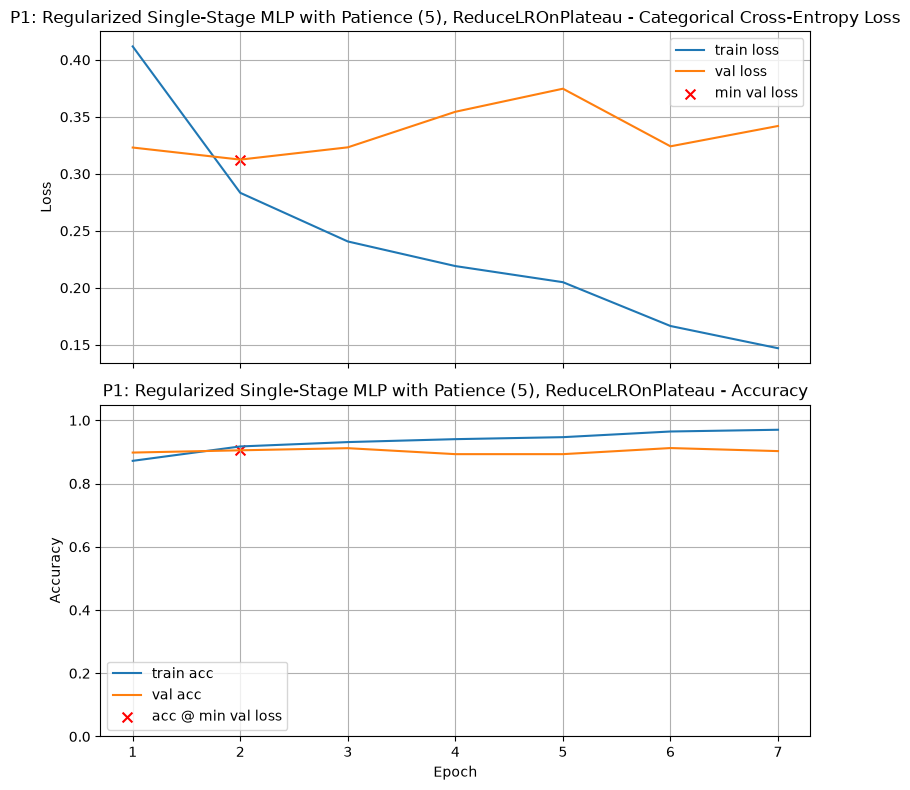

Final Training Loss:            0.1470
Final Training Accuracy:        0.9702
Final Validation Loss:          0.3420
Final Validation Accuracy:      0.9026
Minimum Validation Loss:        0.3125 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9051

Test Loss: 0.2898
Test Accuracy: 0.9077

Validation-Test Gap (accuracy): 0.002531

Execution Time: 00:01:10


In [12]:
# Construct a fresh frozen MobileNetV2 backbone

base_model1 = make_base_model_pooled()

model_reg_single_stage_MLP = models.Sequential([
    base_model1,
    Dense(256, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.35),
    Dense(num_classes, activation='softmax', kernel_regularizer=l2reg)  # use your Intel num_classes (6)
])

train_and_test(model_reg_single_stage_MLP, patience=5, callbacks=[reduce_lr], title="P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.8459 - loss: 0.5555 - val_accuracy: 0.9041 - val_loss: 0.3945 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9036 - loss: 0.3963 - val_accuracy: 0.9098 - val_loss: 0.3774 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9188 - loss: 0.3508 - val_accuracy: 0.8969 - val_loss: 0.3963 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9338 - loss: 0.3083 - val_accuracy: 0.9073 - val_loss: 0.3897 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9363 - loss: 0.2956
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9363 - loss: 0.2956 - val_accuracy: 0.9069 - val_loss: 0.3830 - le

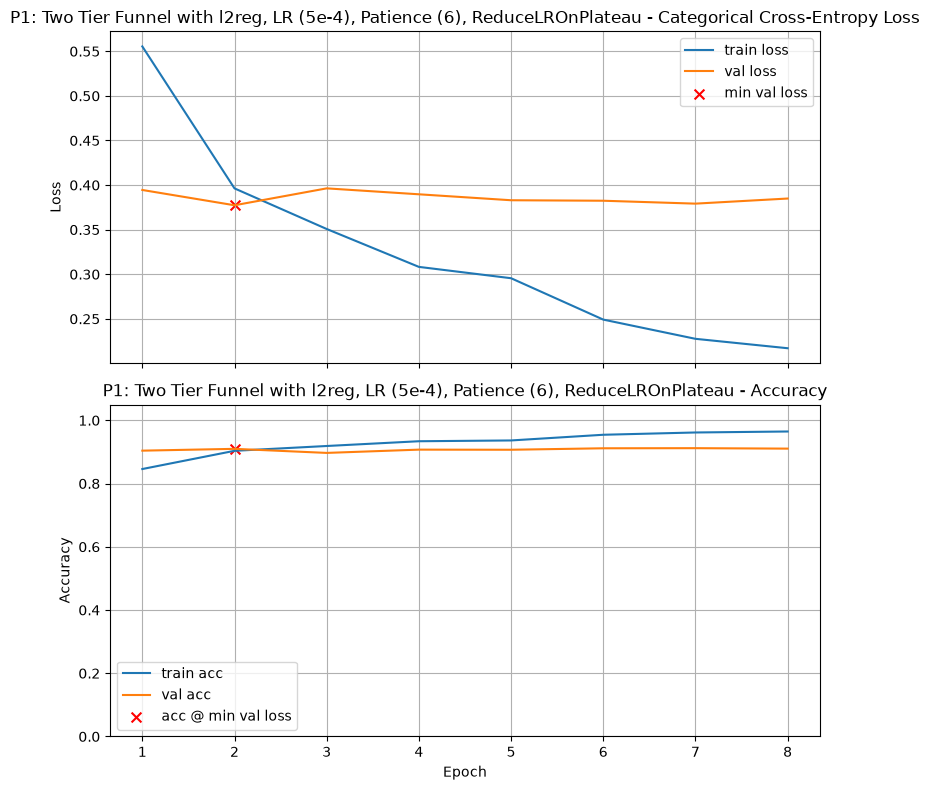

Final Training Loss:            0.2171
Final Training Accuracy:        0.9646
Final Validation Loss:          0.3849
Final Validation Accuracy:      0.9105
Minimum Validation Loss:        0.3774 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9098

Test Loss: 0.3586
Test Accuracy: 0.9130

Validation-Test Gap (accuracy): 0.003228

Execution Time: 00:01:28


In [13]:
# Construct a fresh frozen MobileNetV2 backbone

base_model2 = make_base_model_pooled()

model_two_tier_funnel = models.Sequential([
    base_model2,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel, lr_schedule=5e-4, patience=6, callbacks=[reduce_lr], title="P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8052 - loss: 0.5972 - val_accuracy: 0.8902 - val_loss: 0.3182
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8738 - loss: 0.3861 - val_accuracy: 0.8973 - val_loss: 0.3080
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8823 - loss: 0.3440 - val_accuracy: 0.8951 - val_loss: 0.2995
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8850 - loss: 0.3331 - val_accuracy: 0.8987 - val_loss: 0.2880
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8870 - loss: 0.3243 - val_accuracy: 0.8969 - val_loss: 0.2918
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8907 - loss: 0.3150 - val_accuracy: 0.8969 - val_loss: 0.2949
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8940 - loss: 0.3065 - val_accuracy: 0.8927 - val_loss: 0.3050
Epoc

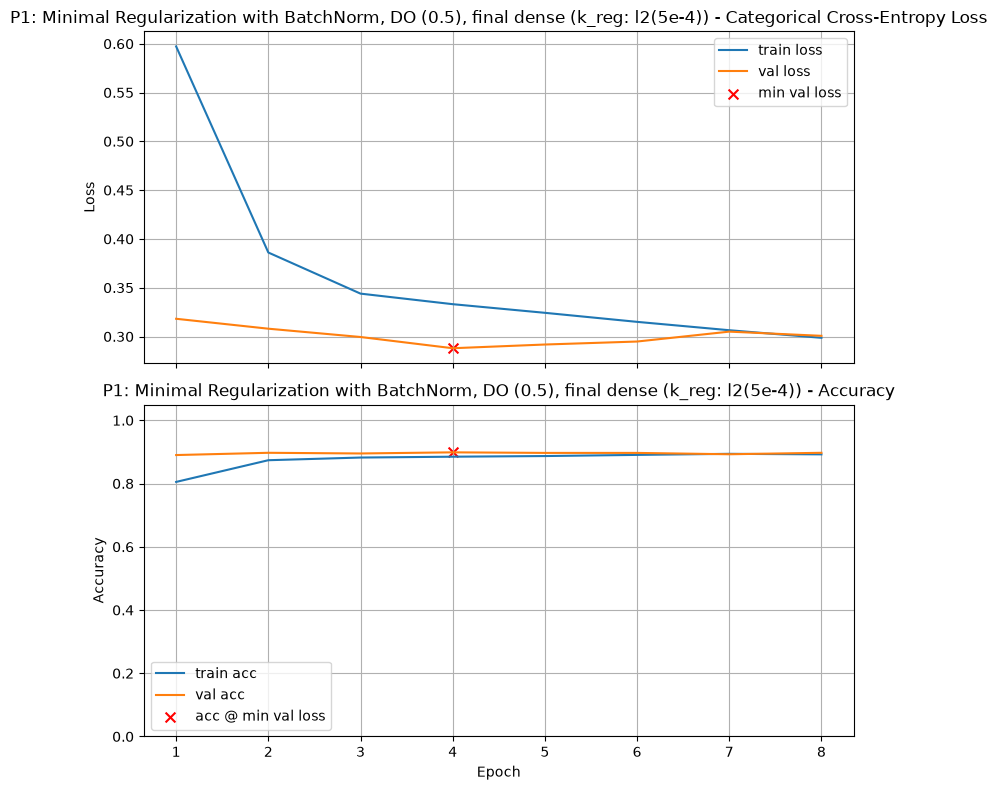

Final Training Loss:            0.2987
Final Training Accuracy:        0.8923
Final Validation Loss:          0.3007
Final Validation Accuracy:      0.8973
Minimum Validation Loss:        0.2880 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8987

Test Loss: 0.2545
Test Accuracy: 0.9040

Validation-Test Gap (accuracy): 0.005284

Execution Time: 00:01:14


In [14]:
# Construct a fresh frozen MobileNetV2 backbone

base_model3 = make_base_model_pooled()

model_minimal_reg = models.Sequential([
    base_model3,
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(5e-4))  # use your Intel num_classes (6)
])

train_and_test(model_minimal_reg, patience=4, title="P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.8312 - loss: 0.6457 - val_accuracy: 0.9001 - val_loss: 0.4221 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8972 - loss: 0.4406 - val_accuracy: 0.9130 - val_loss: 0.3972 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9071 - loss: 0.4054 - val_accuracy: 0.9058 - val_loss: 0.4017 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9203 - loss: 0.3677 - val_accuracy: 0.9058 - val_loss: 0.3927 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9273 - loss: 0.3375 - val_accuracy: 0.9087 - val_loss: 0.3944 - learning_rate: 5.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9303 - loss: 0.3202 - val_accuracy: 0.9034 - val_loss: 0.

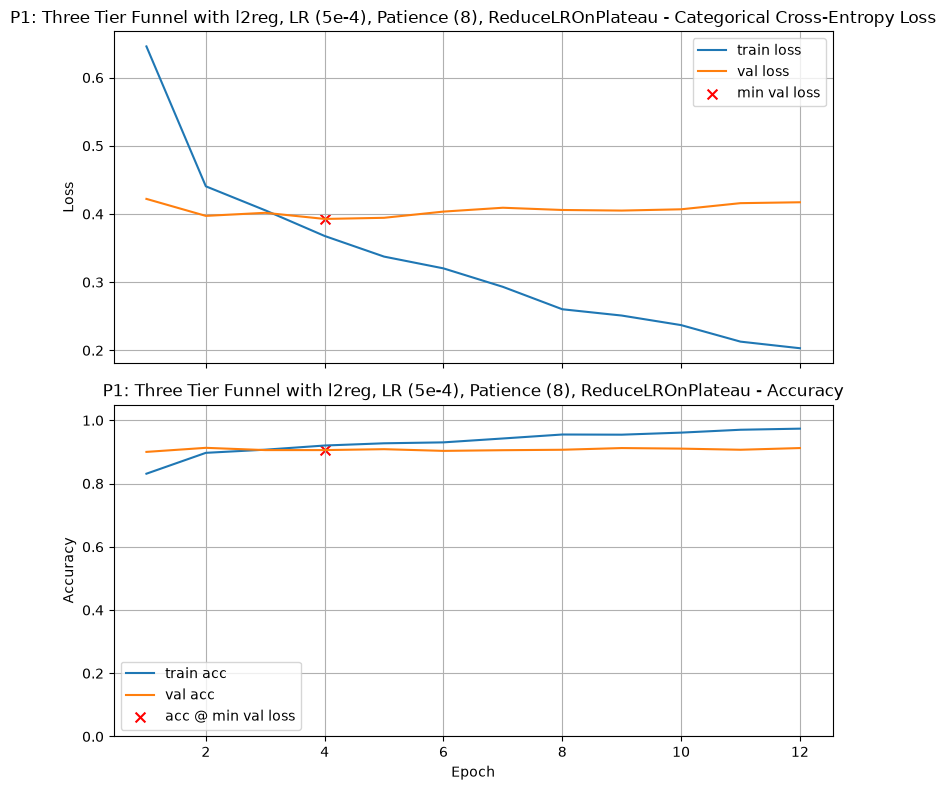

Final Training Loss:            0.2031
Final Training Accuracy:        0.9736
Final Validation Loss:          0.4172
Final Validation Accuracy:      0.9123
Minimum Validation Loss:        0.3927 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9058

Test Loss: 0.3621
Test Accuracy: 0.9160

Validation-Test Gap (accuracy): 0.010151

Execution Time: 00:02:24


In [15]:
# Construct a fresh frozen MobileNetV2 backbone

base_model4 = make_base_model_pooled()

model_three_tier_funnel = models.Sequential([
    base_model4,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel, lr_schedule=5e-4, patience=8, callbacks=[reduce_lr], title="P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8502 - loss: 0.5573 - val_accuracy: 0.9058 - val_loss: 0.3925
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9076 - loss: 0.3897 - val_accuracy: 0.9048 - val_loss: 0.3875
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9207 - loss: 0.3462 - val_accuracy: 0.9051 - val_loss: 0.3904
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9288 - loss: 0.3173 - val_accuracy: 0.9041 - val_loss: 0.3952
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9380 - loss: 0.2880 - val_accuracy: 0.8959 - val_loss: 0.4139
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9481 - loss: 0.2627 - val_accuracy: 0.9048 - val_loss: 0.3942
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9493 - loss: 0.2574 - val_accuracy: 0.9073 - val_loss: 0.3913
Epoch 8/500
351/351 ━━━━━

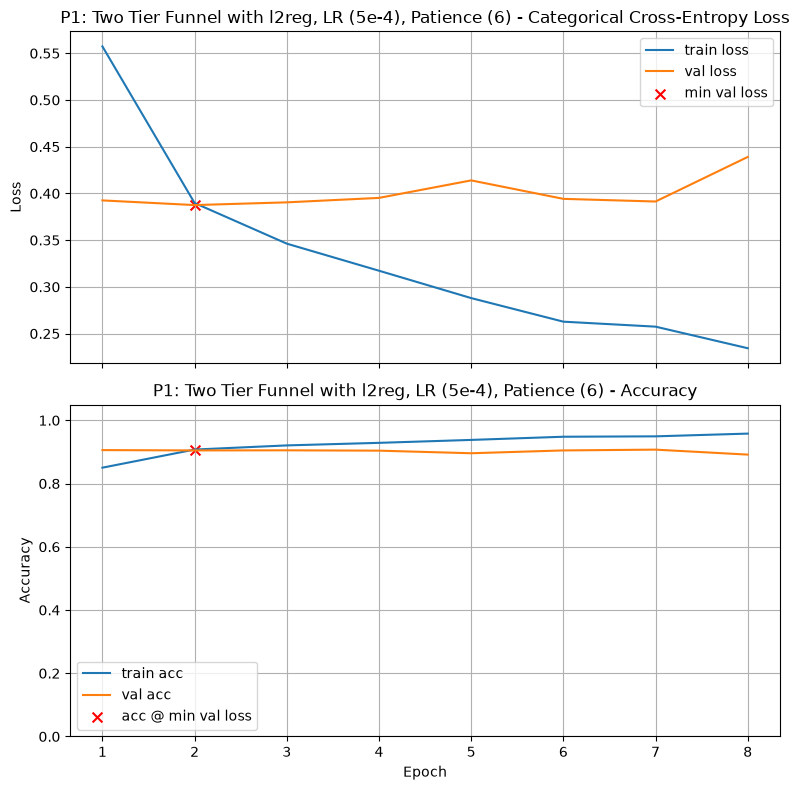

Final Training Loss:            0.2343
Final Training Accuracy:        0.9580
Final Validation Loss:          0.4390
Final Validation Accuracy:      0.8916
Minimum Validation Loss:        0.3875 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9048

Test Loss: 0.3691
Test Accuracy: 0.9067

Validation-Test Gap (accuracy): 0.001888

Execution Time: 00:01:29


In [16]:
# Construct a fresh frozen MobileNetV2 backbone

base_model5 = make_base_model_pooled()

model_two_tier_funnel2 = models.Sequential([
    base_model5,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel2, lr_schedule=5e-4, patience=6, title="P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.8295 - loss: 0.6580 - val_accuracy: 0.9066 - val_loss: 0.4206
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.8931 - loss: 0.4475 - val_accuracy: 0.9019 - val_loss: 0.4143
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9085 - loss: 0.3990 - val_accuracy: 0.9005 - val_loss: 0.4189
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9191 - loss: 0.3629 - val_accuracy: 0.8976 - val_loss: 0.4215
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9288 - loss: 0.3337 - val_accuracy: 0.9069 - val_loss: 0.3996
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9347 - loss: 0.3195 - val_accuracy: 0.9087 - val_loss: 0.3969
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9384 - loss: 0.3040 - val_accuracy: 0.9094 - val_loss: 0.4103
Epoch 8/500
351/351 ━━━

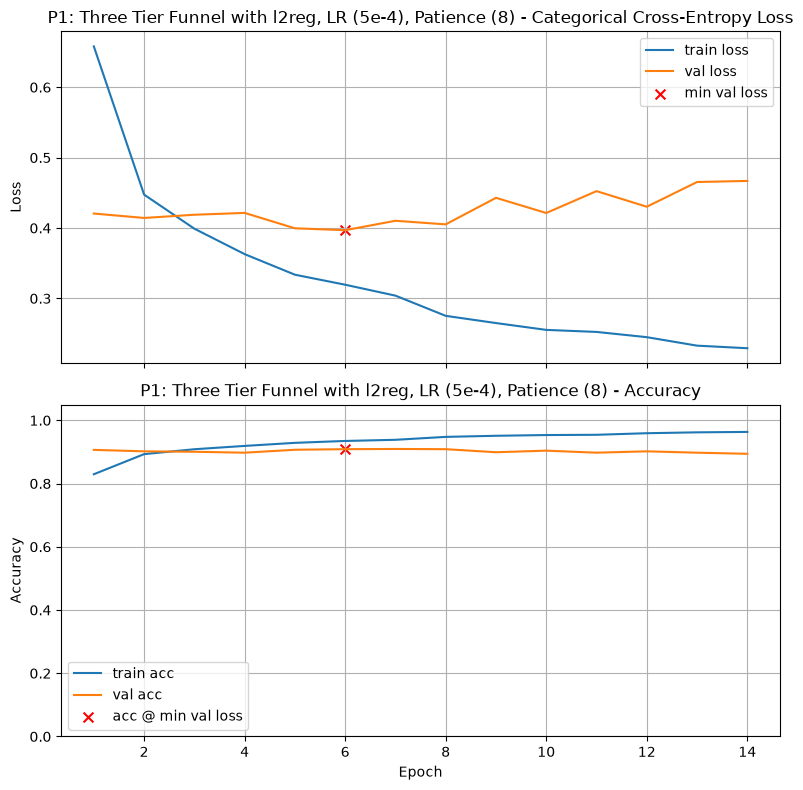

Final Training Loss:            0.2293
Final Training Accuracy:        0.9633
Final Validation Loss:          0.4669
Final Validation Accuracy:      0.8941
Minimum Validation Loss:        0.3969 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9087

Test Loss: 0.3705
Test Accuracy: 0.9130

Validation-Test Gap (accuracy): 0.004298

Execution Time: 00:02:49


In [17]:
# Construct a fresh frozen MobileNetV2 backbone

base_model6 = make_base_model_pooled()

model_three_tier_funnel2 = models.Sequential([
    base_model6,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel2, lr_schedule=5e-4, patience=8, title="P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.8733 - loss: 0.4080 - val_accuracy: 0.8969 - val_loss: 0.3338 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9179 - loss: 0.2828 - val_accuracy: 0.9076 - val_loss: 0.3196 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9280 - loss: 0.2505 - val_accuracy: 0.9044 - val_loss: 0.3297 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9375 - loss: 0.2257 - val_accuracy: 0.9080 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 5/500
349/351 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9489 - loss: 0.2017
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9488 - loss: 0.2020 - val_accuracy: 0.8951 - val_loss: 0.3504 - learning_rate: 0.0010
Epoch

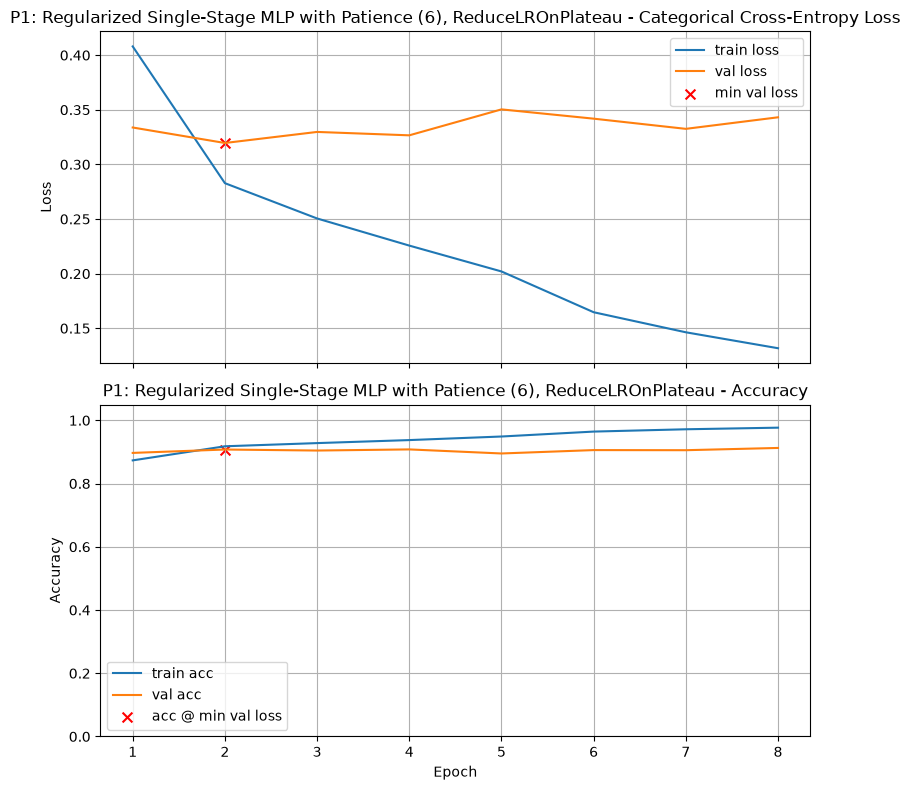

Final Training Loss:            0.1317
Final Training Accuracy:        0.9768
Final Validation Loss:          0.3431
Final Validation Accuracy:      0.9126
Minimum Validation Loss:        0.3196 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9076

Test Loss: 0.2894
Test Accuracy: 0.9107

Validation-Test Gap (accuracy): 0.003035

Execution Time: 00:01:21


In [18]:
# Construct a fresh frozen MobileNetV2 backbone

base_model7 = make_base_model_pooled()

model_reg_single_stage_MLP2 = models.Sequential([
    base_model7,
    Dense(256, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.35),
    Dense(num_classes, activation='softmax', kernel_regularizer=l2reg)  # use your Intel num_classes (6)
])

train_and_test(model_reg_single_stage_MLP2, patience=6, callbacks=[reduce_lr], title="P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Minimal with BatchNorm, DO (0.5)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8045 - loss: 0.6042 - val_accuracy: 0.8980 - val_loss: 0.3076
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8710 - loss: 0.3835 - val_accuracy: 0.8909 - val_loss: 0.3103
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8847 - loss: 0.3419 - val_accuracy: 0.8962 - val_loss: 0.2935
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8866 - loss: 0.3210 - val_accuracy: 0.9019 - val_loss: 0.2810
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8909 - loss: 0.3025 - val_accuracy: 0.9026 - val_loss: 0.2898
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8898 - loss: 0.3001 - val_accuracy: 0.9019 - val_loss: 0.2829
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8939 - loss: 0.3030 - val_accuracy: 0.8969 - val_loss: 0.2969
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8881 - loss: 0.3106 - val_accurac

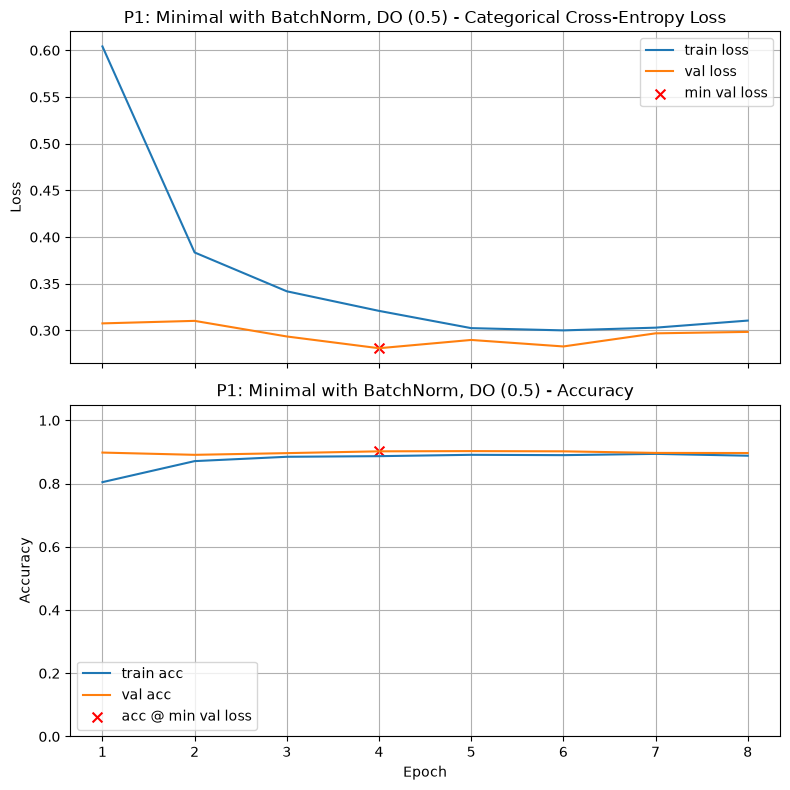

Final Training Loss:            0.3106
Final Training Accuracy:        0.8881
Final Validation Loss:          0.2985
Final Validation Accuracy:      0.8966
Minimum Validation Loss:        0.2810 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9019

Test Loss: 0.2566
Test Accuracy: 0.9047

Validation-Test Gap (accuracy): 0.002741

Execution Time: 00:01:17


In [32]:
# Construct a fresh frozen MobileNetV2 backbone

base_model8 = make_base_model_pooled()

model_minimal = models.Sequential([
    base_model8,
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_minimal, patience=4, title="P1: Minimal with BatchNorm, DO (0.5)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8549 - loss: 0.4161 - val_accuracy: 0.9009 - val_loss: 0.2737 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9037 - loss: 0.2665 - val_accuracy: 0.9098 - val_loss: 0.2560 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9195 - loss: 0.2228 - val_accuracy: 0.9091 - val_loss: 0.2519 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9323 - loss: 0.1838 - val_accuracy: 0.9009 - val_loss: 0.2687 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9398 - loss: 0.1623 - val_accuracy: 0.9019 - val_loss: 0.2720 - learning_rate: 5.0000e-04
Epoch 6/500
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9446 - loss: 0.1474
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy

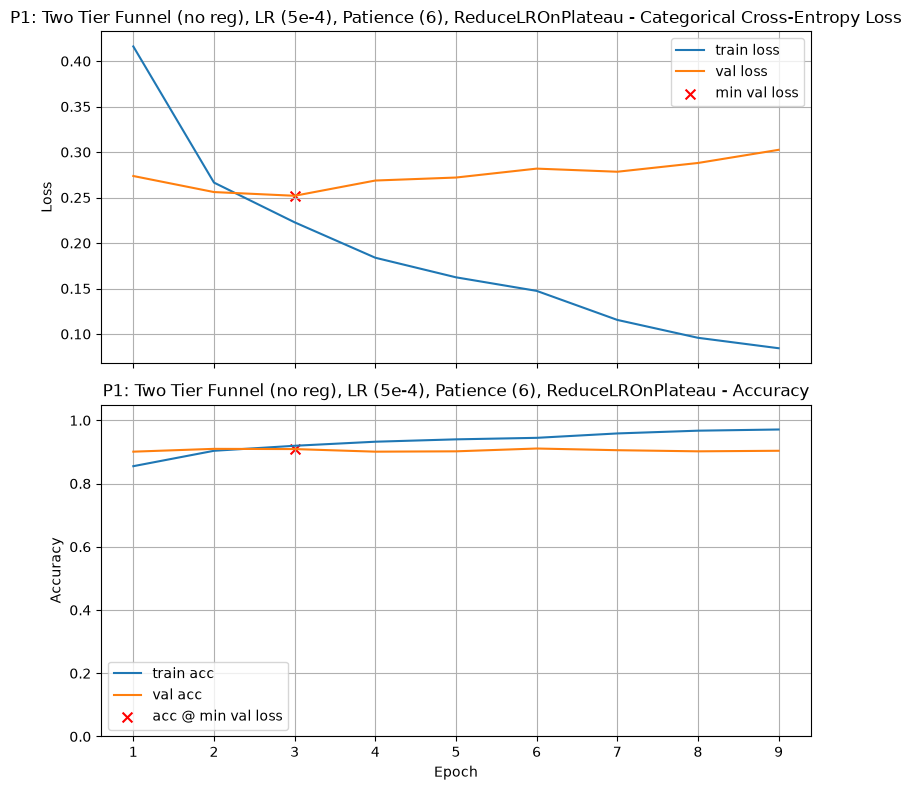

Final Training Loss:            0.0844
Final Training Accuracy:        0.9710
Final Validation Loss:          0.3025
Final Validation Accuracy:      0.9037
Minimum Validation Loss:        0.2519 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9091

Test Loss: 0.2286
Test Accuracy: 0.9130

Validation-Test Gap (accuracy): 0.003941

Execution Time: 00:01:39


In [33]:
# Construct a fresh frozen MobileNetV2 backbone

base_model9 = make_base_model_pooled()

model_two_tier_funnel_no_reg = models.Sequential([
    base_model9,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg, lr_schedule=5e-4, patience=6, callbacks=[reduce_lr], title="P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8604 - loss: 0.4114 - val_accuracy: 0.9048 - val_loss: 0.2669
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9042 - loss: 0.2684 - val_accuracy: 0.9055 - val_loss: 0.2586
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9192 - loss: 0.2183 - val_accuracy: 0.9105 - val_loss: 0.2469
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9285 - loss: 0.1882 - val_accuracy: 0.9133 - val_loss: 0.2474
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9376 - loss: 0.1693 - val_accuracy: 0.9044 - val_loss: 0.2595
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9465 - loss: 0.1428 - val_accuracy: 0.9094 - val_loss: 0.2554
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9524 - loss: 0.1291 - val_accuracy: 0.9055 - val_loss: 0.2755
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9606 - loss: 0.1092 - val_

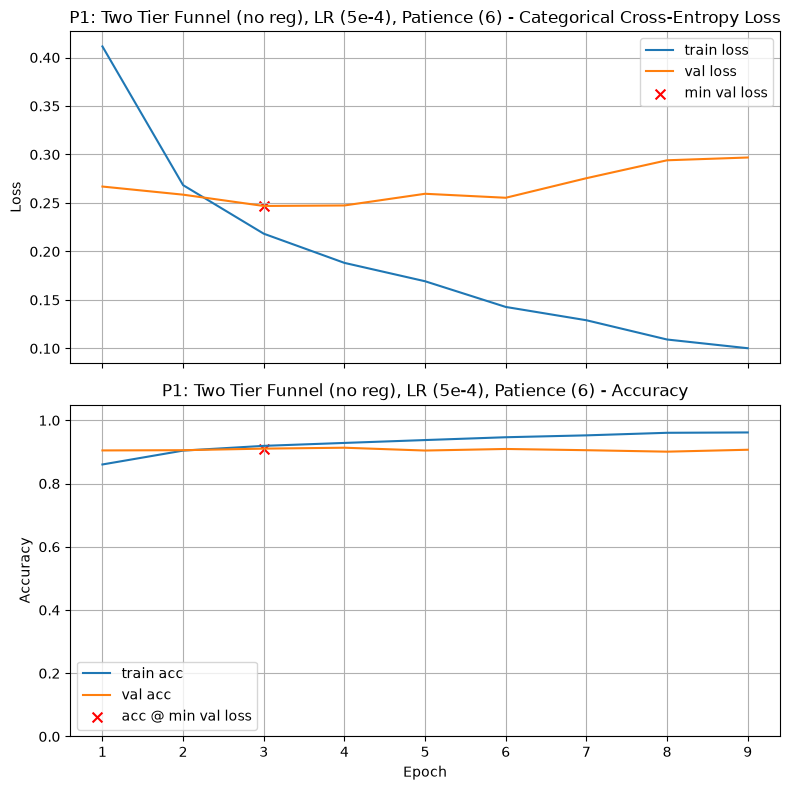

Final Training Loss:            0.1002
Final Training Accuracy:        0.9616
Final Validation Loss:          0.2969
Final Validation Accuracy:      0.9069
Minimum Validation Loss:        0.2469 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9105

Test Loss: 0.2264
Test Accuracy: 0.9163

Validation-Test Gap (accuracy): 0.005848

Execution Time: 00:01:41


In [35]:
# Construct a fresh frozen MobileNetV2 backbone

base_model10 = make_base_model_pooled()

model_two_tier_funnel_no_reg2 = models.Sequential([
    base_model10,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg2, lr_schedule=5e-4, patience=6, title="P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8346 - loss: 0.5045 - val_accuracy: 0.9019 - val_loss: 0.2822
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8957 - loss: 0.3091 - val_accuracy: 0.9098 - val_loss: 0.2521
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9118 - loss: 0.2548 - val_accuracy: 0.9094 - val_loss: 0.2553
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9238 - loss: 0.2193 - val_accuracy: 0.9137 - val_loss: 0.2539
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9272 - loss: 0.1992 - val_accuracy: 0.9044 - val_loss: 0.2665
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9317 - loss: 0.1837 - val_accuracy: 0.8948 - val_loss: 0.2889
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9430 - loss: 0.1591 - val_accuracy: 0.9073 - val_loss: 0.2824
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9466 - loss: 0.1449 - val_

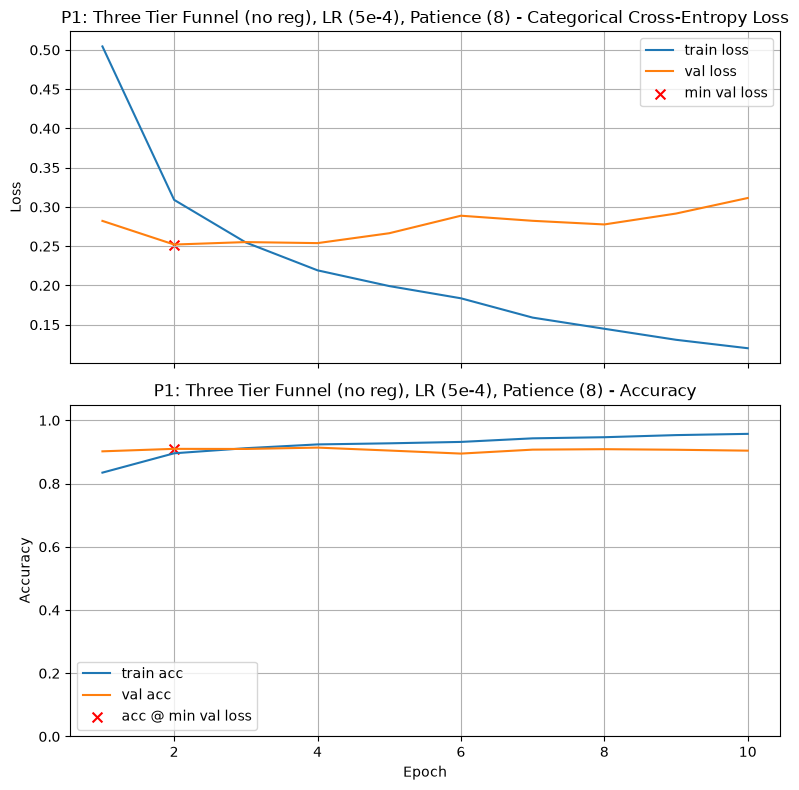

Final Training Loss:            0.1201
Final Training Accuracy:        0.9572
Final Validation Loss:          0.3114
Final Validation Accuracy:      0.9041
Minimum Validation Loss:        0.2521 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9098

Test Loss: 0.2369
Test Accuracy: 0.9083

Validation-Test Gap (accuracy): 0.001438

Execution Time: 00:02:03


In [36]:
# Construct a fresh frozen MobileNetV2 backbone

base_model11 = make_base_model_pooled()

model_three_tier_funnel_no_reg = models.Sequential([
    base_model11,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel_no_reg, lr_schedule=5e-4, patience=8, title="P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8342 - loss: 0.5127 - val_accuracy: 0.9001 - val_loss: 0.2746 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8954 - loss: 0.3033 - val_accuracy: 0.9048 - val_loss: 0.2605 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9111 - loss: 0.2504 - val_accuracy: 0.9091 - val_loss: 0.2504 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9203 - loss: 0.2228 - val_accuracy: 0.9087 - val_loss: 0.2507 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9295 - loss: 0.1970 - val_accuracy: 0.9026 - val_loss: 0.2727 - learning_rate: 5.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9354 - loss: 0.1788
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy

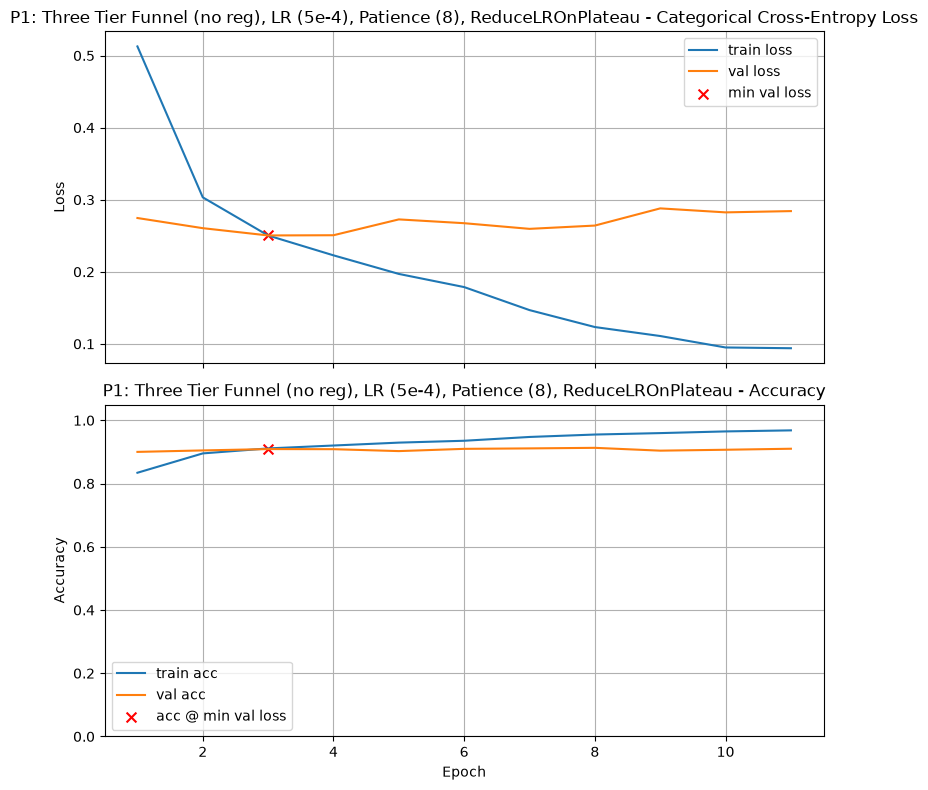

Final Training Loss:            0.0940
Final Training Accuracy:        0.9682
Final Validation Loss:          0.2842
Final Validation Accuracy:      0.9101
Minimum Validation Loss:        0.2504 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9091

Test Loss: 0.2340
Test Accuracy: 0.9113

Validation-Test Gap (accuracy): 0.002275

Execution Time: 00:02:13


In [37]:
# Construct a fresh frozen MobileNetV2 backbone

base_model12 = make_base_model_pooled()

model_three_tier_funnel_no_reg2 = models.Sequential([
    base_model12,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel_no_reg2, lr_schedule=5e-4, patience=8, callbacks=[reduce_lr], title="P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.7695 - loss: 0.6611 - val_accuracy: 0.8884 - val_loss: 0.3329
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8791 - loss: 0.3597 - val_accuracy: 0.8959 - val_loss: 0.2967
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8932 - loss: 0.3096 - val_accuracy: 0.9041 - val_loss: 0.2752
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9049 - loss: 0.2753 - val_accuracy: 0.9069 - val_loss: 0.2653
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9142 - loss: 0.2455 - val_accuracy: 0.9062 - val_loss: 0.2594
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9205 - loss: 0.2268 - val_accuracy: 0.9101 - val_loss: 0.2566
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9250 - loss: 0.2079 - val_accuracy: 0.9094 - val_loss: 0.2539
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9310 - loss: 0.1919 - val_

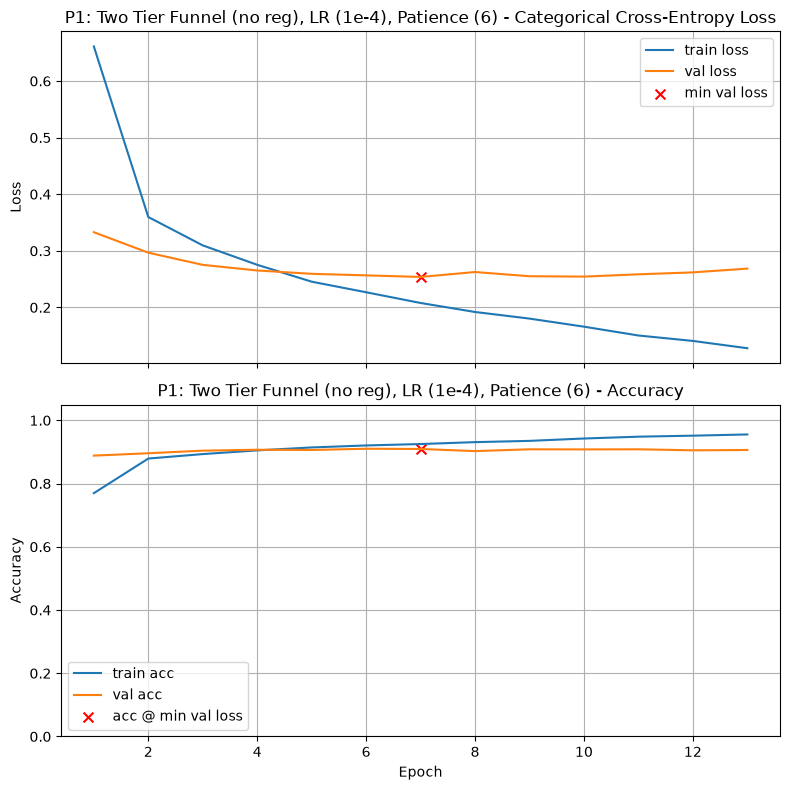

Final Training Loss:            0.1279
Final Training Accuracy:        0.9553
Final Validation Loss:          0.2686
Final Validation Accuracy:      0.9062
Minimum Validation Loss:        0.2539 (Epoch 7)
Validation Accuracy @ Min Loss: 0.9094

Test Loss: 0.2261
Test Accuracy: 0.9167

Validation-Test Gap (accuracy): 0.007252

Execution Time: 00:02:21


In [40]:
# Construct a fresh frozen MobileNetV2 backbone

base_model13 = make_base_model_pooled()

model_two_tier_funnel_no_reg3 = models.Sequential([
    base_model13,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg3, lr_schedule=1e-4, patience=6, title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.7728 - loss: 0.6529 - val_accuracy: 0.8912 - val_loss: 0.3211
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8771 - loss: 0.3638 - val_accuracy: 0.9041 - val_loss: 0.2813
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8935 - loss: 0.3116 - val_accuracy: 0.9062 - val_loss: 0.2646
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9043 - loss: 0.2764 - val_accuracy: 0.9105 - val_loss: 0.2569
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9099 - loss: 0.2522 - val_accuracy: 0.9108 - val_loss: 0.2525
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9212 - loss: 0.2285 - val_accuracy: 0.9116 - val_loss: 0.2487
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9243 - loss: 0.2088 - val_accuracy: 0.9116 - val_loss: 0.2501
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9338 - loss: 0.1940 - val_

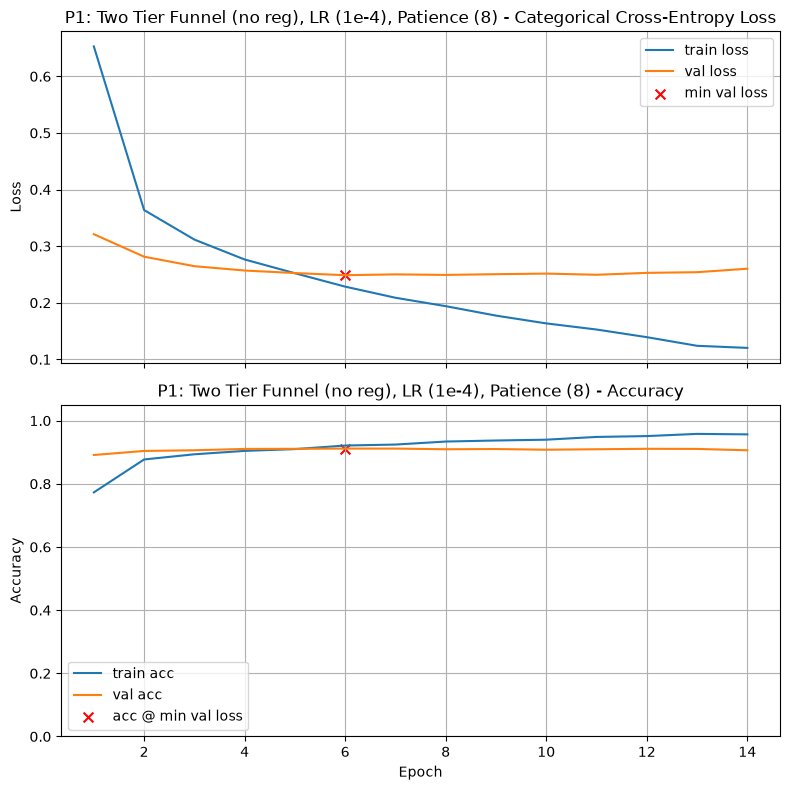

Final Training Loss:            0.1202
Final Training Accuracy:        0.9565
Final Validation Loss:          0.2601
Final Validation Accuracy:      0.9062
Minimum Validation Loss:        0.2487 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9116

Test Loss: 0.2303
Test Accuracy: 0.9107

Validation-Test Gap (accuracy): 0.000888

Execution Time: 00:02:31


In [43]:
# Construct a fresh frozen MobileNetV2 backbone

base_model14 = make_base_model_pooled()

model_two_tier_funnel_no_reg4 = models.Sequential([
    base_model14,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg4, lr_schedule=1e-4, patience=8, title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.7710 - loss: 0.6760 - val_accuracy: 0.8976 - val_loss: 0.3151 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8807 - loss: 0.3569 - val_accuracy: 0.9037 - val_loss: 0.2806 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9011 - loss: 0.2990 - val_accuracy: 0.9098 - val_loss: 0.2660 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9054 - loss: 0.2756 - val_accuracy: 0.9105 - val_loss: 0.2570 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9140 - loss: 0.2450 - val_accuracy: 0.9098 - val_loss: 0.2580 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9207 - loss: 0.2252 - val_accuracy: 0.9137 - val_loss: 0.2527 - learning_rate: 1.0000e-04
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - a

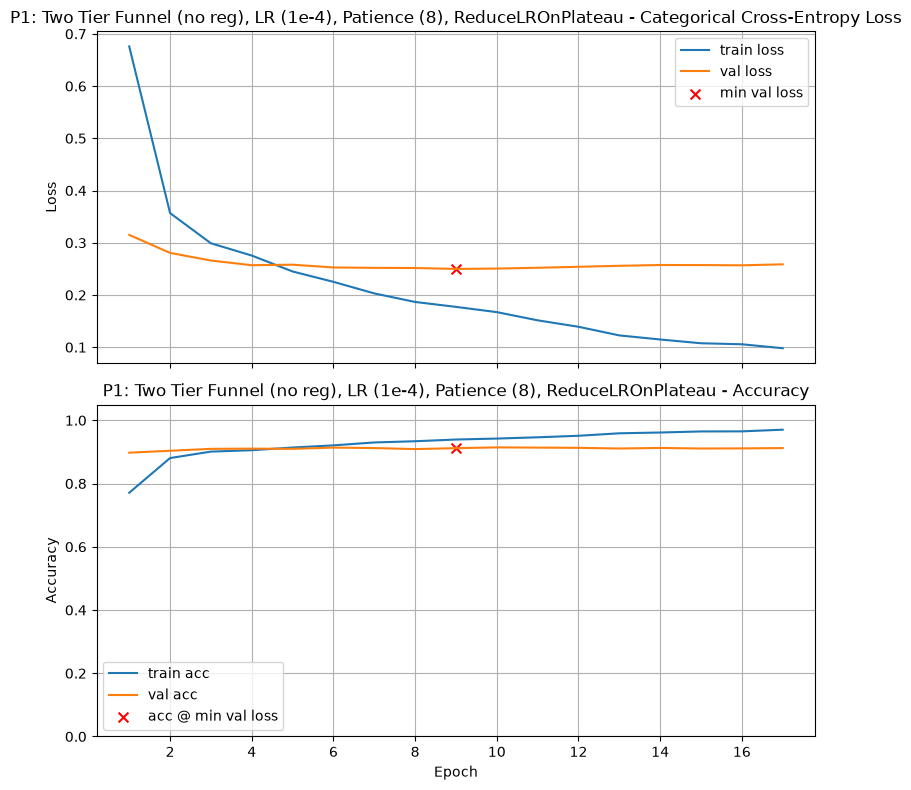

Final Training Loss:            0.0981
Final Training Accuracy:        0.9703
Final Validation Loss:          0.2587
Final Validation Accuracy:      0.9123
Minimum Validation Loss:        0.2499 (Epoch 9)
Validation Accuracy @ Min Loss: 0.9119

Test Loss: 0.2241
Test Accuracy: 0.9120

Validation-Test Gap (accuracy): 0.000088

Execution Time: 00:03:13


In [46]:
# Construct a fresh frozen MobileNetV2 backbone

base_model15 = make_base_model_pooled()

model_two_tier_funnel_no_reg5 = models.Sequential([
    base_model15,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg5, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_5807/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.7684 - loss: 0.7727 - val_accuracy: 0.8894 - val_loss: 0.4183 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8758 - loss: 0.4587 - val_accuracy: 0.9016 - val_loss: 0.3811 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8945 - loss: 0.4038 - val_accuracy: 0.8998 - val_loss: 0.3683 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9021 - loss: 0.3697 - val_accuracy: 0.9098 - val_loss: 0.3549 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9179 - loss: 0.3379 - val_accuracy: 0.9087 - val_loss: 0.3487 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9207 - loss: 0.3260 - val_accuracy: 0.9080 - val_loss: 0.3453 - learning_rate: 1.0000e-04
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - a

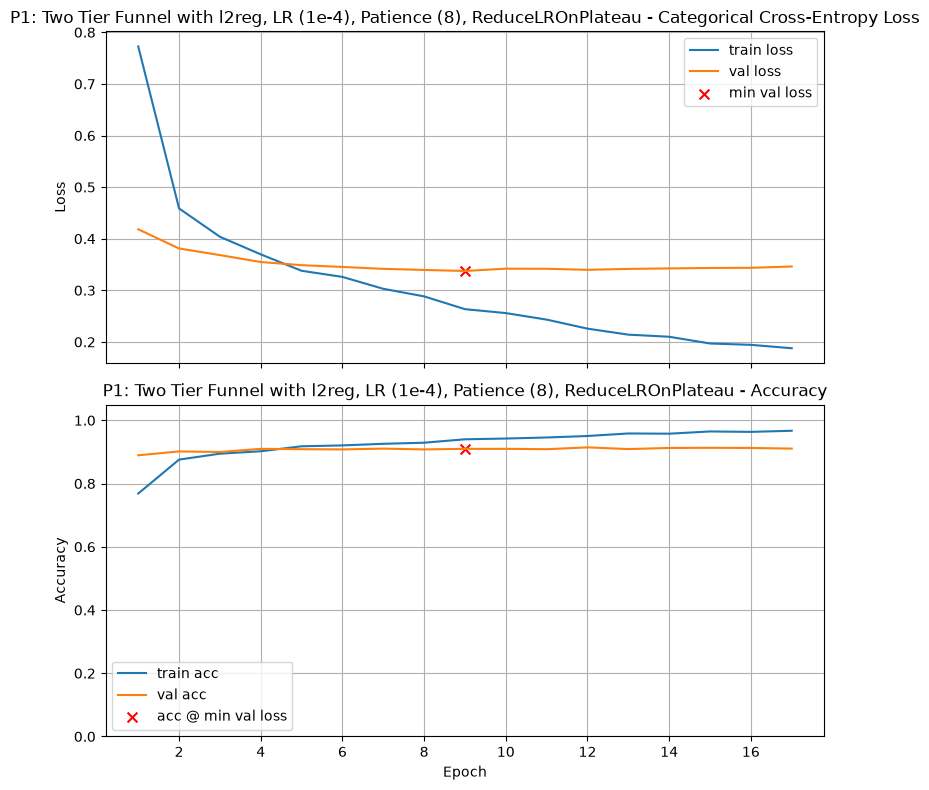

Final Training Loss:            0.1878
Final Training Accuracy:        0.9670
Final Validation Loss:          0.3461
Final Validation Accuracy:      0.9105
Minimum Validation Loss:        0.3375 (Epoch 9)
Validation Accuracy @ Min Loss: 0.9098

Test Loss: 0.3126
Test Accuracy: 0.9183

Validation-Test Gap (accuracy): 0.008562

Execution Time: 00:03:15


In [49]:
# Construct a fresh frozen MobileNetV2 backbone

base_model16 = make_base_model_pooled()

model_two_tier_funnel_with_reg = models.Sequential([
    base_model16,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_with_reg, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau")

In [51]:
print_results()

P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau	0.9119	9
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)	0.9116	6
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)	0.9105	3
P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau	0.9098	2
P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)	0.9098	2
P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau	0.9098	9
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)	0.9094	7
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau	0.9091	3
P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau	0.9091	3
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)	0.9087	6
P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau	0.9076	2
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau	0.9058	4
P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau	0.9051	2
P1: Two Tier Funnel

# Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that suggest about the role of head design and hyperparameters when the backbone is frozen?

**Instructions:**

- Write a single paragraph (3–5 sentences).
- Identify the head architecture and experiment that performed best.
- Briefly compare it with the other experiments, referring to specific design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate, ReduceLROnPlateau).
- Explain which of these differences you think were most important, based on your observed training and validation results.
- Conclude with what your experiments suggest about designing classification heads when the backbone is frozen.


**Your paragraph here (5pts):**

> The best head architecture was the unregularized two-tier funnel (Dense: 512 -> 128), which had a validation accuracy of 0.9119 at epoch 9 with a lower learning rate (1e-4) and default patience (8) and ReduceOnPlateau. The two-tier funnel approach consistently outperformed the baseline (0.8991) and single block (0.9019, 0.9051) designs showing that moderate depth results in greater accuracy rather than a more direct smaller head. Removing L2 regularization while using a lower learning rate and a moderate patience window proved to be the most decisive factors outside of the depth of the head. ReduceLROnPlateau produced mixed results in accuracy improvement, but pairing it with a lower learning rate gave the optimizer the ability to reach a higher overall validation accuracy. These results suggest that when transfer learning with a completely frozen backbone, classification heads benefit most from moderate depth (three tier seemed excessive) and non-regularized dense layers.

**Validation Accuracy here (15 pts):**

In [52]:
# Set a1 to the validation accuracy found by your best model for this problem. 

a1 = results['P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau'][0]             # Replace 0.0 with your answer

In [53]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem         

print(f'a1 = {a1:.4f}') 


a1 = 0.9119


## Problem Two — Training MobileNetV2 with the Backbone Unfrozen

**Goal.** Use the architecture of one of your best heads from Problem 1, but now make the MobileNetV2 backbone trainable so that the entire network can adapt to the Intel Image dataset.

**Setup.** Build a new MobileNetV2 backbone with `trainable=True`. It already applies Global Average Pooling and outputs a 1280-D vector, so do not add another pooling layer.

```python
base = make_base_model_pooled(
    trainable=True
)  # MobileNetV2(include_top=False, pooling="avg")
```

### To Do

1. **Design at least three experiments** with the MobileNetV2 backbone fully unfrozen. Use the architecture of one of your best heads from Problem 1 and vary one or more of the following:

   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * training stability,
   * convergence behavior,
   * and validation performance trends.

   Use these runs to **narrow down reasonable configurations**, not to identify a single “optimal” setting.

3. **Select one configuration**, set `DATA_FRACTION = 1.0`, rerun the notebook to train on the full dataset, and use this run when answering the graded questions.

### Notes

* Training a pretrained backbone generally requires a **much smaller learning rate** than training only a new classification head. Values such as \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points.
* Small changes in relative performance between experiments using a reduced dataset and the full dataset are expected.
* Each experiment should construct a **new model** so that experiments do not inherit weights from previous runs.



In [22]:
# Your code here; add as many cells as you need


### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which fully unfrozen configuration worked best for you, and what does that suggest about the role of head design and training hyperparameters when the MobileNetV2 backbone is trainable?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (e.g., dense layers, dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about training a model when the pretrained backbone is fully unfrozen.



**Your paragraph here (5pts):**

> Replace this sentence with your answer. 

**Validation accuracy here (15 pts):**

In [23]:
# Set a2 to the validation accuracy found by your best model for this problem. 

a2 = 0.0             # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem       

print(f'a2 = {a2:.4f}') 

a2 = 0.0000


## Problem Three — Unfreezing Layers

**Goal.** Keep most of the pretrained MobileNetV2 backbone frozen and **unfreeze only the last \(N\) layers** for fine-tuning.

(In Problem 4, you will instead explore unfreezing the top **\(K\) MobileNetV2 blocks**.)

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a 1280-D feature vector. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the last \(N\) layers using the following approach:

```python
N = 20

base_model = make_base_model_pooled()
base_model.trainable = True

for layer in base_model.layers[:-N]:
    layer.trainable = False
```

### To Do

1. **Design at least three experiments** in which only the last \(N\) backbone layers are unfrozen. Vary one or more of the following:

   * \(N \in \{20, 40, 80\}\)
   * **Head architecture** (select one from Problem 1)
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more layers are unfrozen,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of partial unfreezing**, not to identify a single globally optimal configuration.

3. **Select one configuration** (choice of \(N\) and training strategy), set `DATA_FRACTION = 1.0`, and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* As more layers are unfrozen, the model typically becomes **more sensitive to the learning rate**.
* Learning rates around \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points for partial fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



In [25]:
# Your code here; add as many cells as you need



### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which partial-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(N\) layers of MobileNetV2?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(N\) of unfrozen layers**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about how much of a pretrained backbone should be unfrozen during fine-tuning.



**Your paragraph here (5pts):**

> Replace this sentence with your answer. 

**Validation accuracy here (15 pts):**

In [26]:
# Set a3 to the validation accuracy found by your best model for this problem. 

a3 = 0.0             # Replace 0.0 with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3 = {a3:.4f}') 

a3 = 0.0000


## Problem Four — Unfreezing Convolution Blocks

**Goal.** Fine-tune MobileNetV2 by unfreezing the **last $K$ convolutional stages/blocks** rather than the last $N$ individual layers, as in Problem 3. This provides a more meaningful way to control how much of the pretrained backbone is allowed to adapt.

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a **1280-D feature vector**. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the top $K$ stages using the following approach:

```python
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_model = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )
```

For example:

* $K=1$ unfreezes only `Conv_1`.
* $K=2$ unfreezes `block_16` and `Conv_1`.
* $K=3$ unfreezes `block_15`, `block_16`, and `Conv_1`.

### To Do

1. **Design at least three experiments** in which the **last $K$ stages are unfrozen**. Vary one or more of the following:

   * $K \in {1, 2, 3, 5}$
     *(Here, $K$ counts stages/blocks, not individual Keras layers.)*
   * **BatchNormalization strategy:** keep BN frozen vs. allow BN layers in the selected blocks to be trainable.
   * **Head architecture** (select one from Problem 1).
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more blocks are unfrozen,
   * whether making BatchNormalization layers trainable helps or destabilizes training,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of block-level fine-tuning** and to narrow down reasonable configurations, rather than to identify a single globally optimal setting.

3. **Select one configuration** (choice of $K$, BatchNormalization strategy, and training strategy), set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* Your backbone was built with `pooling="avg"`, so **do not** add another `GlobalAveragePooling2D()` layer.
* Unfreezing more blocks generally makes training **more sensitive to the learning rate** and may increase instability; this is part of what you are investigating.
* Learning rates around $1\times10^{-5}$ to $3\times10^{-5}$ are reasonable starting points for block-level fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



In [28]:
# Your code here; add as many cells as you need



### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which block-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(K\) MobileNetV2 blocks?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(K\) of unfrozen blocks**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* If you experimented with BatchNormalization, comment briefly on whether keeping BN frozen or allowing it to train appeared to help or destabilize training.
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about selecting how many pretrained blocks to unfreeze during fine-tuning.



**Your paragraph here (5pts):**

> Replace this sentence with your answer. 

**Validation accuracy (15pts):**

In [29]:
# Set a4 to the validation accuracy found by your best model for this problem. 

a4 = 0.0             # Replace 0.0 with your answer

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4 = {a4:.4f}') 

a4 = 0.0000


## Problem 5: Final Reflection

Run the next cell and consider all your experiments in this homework. 

This reflection question is worth 5 points. 

In [31]:
# Print out summary of validation accuracy for each experiment

print_results()

P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau	0.9098	2
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)	0.9087	6
P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau	0.9076	2
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau	0.9058	4
P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau	0.9051	2
P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)	0.9048	2
Model Baseline                          	0.8991	2
P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))	0.8987	4


### Graded Question

### Final Reflection

Looking across the validation accuracies from your **full-dataset runs**, what patterns or lessons stand out from the different transfer-learning strategies you explored?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Compare the overall results from the frozen backbone, fully trainable backbone, partial layer unfreezing, and block-level unfreezing experiments.
* Highlight at least one design choice or training hyperparameter that appeared especially important.
* Mention any result that surprised you or differed from what you expected, if applicable.
* Conclude with a brief takeaway about what you learned about transfer learning from the homework.



**Your paragraph here (5pts):**

> Replace this sentence with your answer. 

## Appendix: What is MobileNetV2 (in plain English)?

`MobileNetV2` is a lightweight convolutional neural network (CNN) designed for efficient inference on resource-constrained devices while maintaining strong image-classification accuracy.

It achieves this with two important ideas:

1. **Depthwise-separable convolutions**

   Instead of using one expensive 3×3 convolution that mixes spatial information and channels at the same time, MobileNetV2 separates the operation into two steps:

   * a **depthwise 3×3 convolution**, which applies one spatial filter to each input channel separately, followed by
   * a **pointwise 1×1 convolution**, which mixes information across channels.

   This greatly reduces the number of parameters and computations compared with a standard convolution. ([arXiv][1])

2. **Inverted residual blocks with a linear bottleneck**

   A typical MobileNetV2 block has the following structure:

   * **Expand (1×1 convolution):** increase the number of channels, often by a factor of about 6, and apply a nonlinear activation.
   * **Depthwise (3×3 convolution):** process each channel separately and apply a nonlinear activation.
   * **Project (1×1 convolution):** reduce the number of channels again, but **without** applying a nonlinear activation. This is the **linear bottleneck**.

   If the input and output shapes match and the stride is 1, the block also adds a **skip connection**.

   The term **inverted residual** refers to the fact that the representation becomes wide inside the block and narrow again at the output, rather than the other way around.

   The final linear projection helps preserve information when the representation is compressed back to a lower-dimensional space. ([arXiv][1])

---

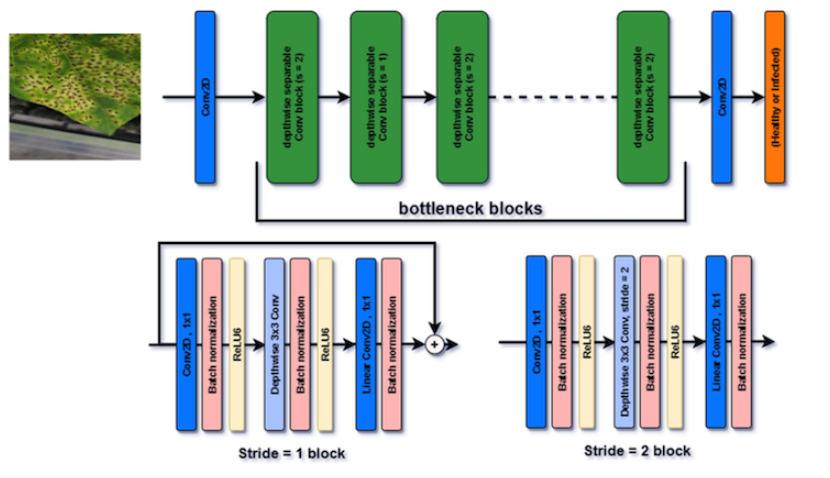

---

### What was MobileNetV2 trained on?

The Keras ImageNet weights for MobileNetV2 were trained on **ImageNet-1K**, a standard image-classification dataset containing:

* **1,281,167** training images
* **50,000** validation images
* **100,000** test images
* **1000 classes**

A common input size for MobileNetV2 is **224×224**. ([ImageNet][2])

For this homework, we use smaller **150×150** images to reduce training time.

Because we use:

```python
include_top=False
```

the pretrained convolutional backbone can operate on image sizes other than 224×224.

---

### Preprocessing

The preprocessing used for a pretrained network should match the preprocessing used when that network was originally trained.

For MobileNetV2, Keras provides:

```python
mobilenet_v2.preprocess_input
```

This function takes pixel values in their original approximately **0–255** range and scales them to approximately **[-1, 1]**.

In this homework, the image-loading pipeline applies this preprocessing before passing images to MobileNetV2. ([keras.io][3])

---

### How Keras exposes MobileNetV2

The following Keras call:

```python
tf.keras.applications.mobilenet_v2.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

returns a pretrained MobileNetV2 backbone with the original ImageNet classification head removed.

With:

```python
pooling="avg"
```

Keras applies **Global Average Pooling** to the final convolutional feature map. The result is a **1280-dimensional feature vector** for each image.

To use this backbone as a **frozen feature extractor**, we additionally set:

```python
base_model.trainable = False
```

The classification head that we add afterward can then be trained while the pretrained MobileNetV2 weights remain unchanged.

---

### What happens if `pooling="avg"` is omitted?

Without pooling, the backbone produces a spatial feature map rather than a single feature vector.

For a 224×224 input image, this feature map is typically:

```text
7 × 7 × 1280
```

Before connecting this to Dense layers, we would normally reduce the spatial dimensions using:

```python
GlobalAveragePooling2D()
```

which produces a 1280-dimensional vector.

`GlobalMaxPooling2D()` is another possible choice.

Using:

```python
Flatten()
```

is usually less attractive here because it would convert:

```text
7 × 7 × 1280
```

into:

```text
62,720
```

features, creating a much larger classification head.

In this homework, however, we use:

```python
pooling="avg"
```

inside MobileNetV2 itself, so **do not add another `GlobalAveragePooling2D()` layer**.

---

### How we use MobileNetV2 in this homework

We will experiment with several ways of using the pretrained backbone:

* **Frozen feature extraction:** keep all MobileNetV2 layers frozen and train only a new classification head.
* **Fully trainable backbone:** allow all MobileNetV2 layers to be updated during training.
* **Partial unfreezing:** keep most of the backbone frozen while allowing only selected upper layers or blocks to be updated.

These experiments let us investigate how much of the pretrained representation should be preserved and how much should be adapted to the Intel Image Classification dataset.

---

### TL;DR Summary

* Think of a MobileNetV2 block as:

  **expand → depthwise convolution → project (+ optional skip connection)**

* MobileNetV2 was pretrained to distinguish **1000 ImageNet classes**.

* In this homework, we reuse those learned visual features and train the model for our **6 Intel image classes**.

* With:

  ```python
  include_top=False,
  pooling="avg"
  ```

  the backbone outputs a **1280-D feature vector**.

* To use the backbone as a frozen feature extractor, set:

  ```python
  base_model.trainable = False
  ```

* Always match preprocessing to the pretrained backbone. For MobileNetV2, use:

  ```python
  mobilenet_v2.preprocess_input
  ```

  which scales the original pixel values to approximately **[-1, 1]**. ([keras.io][3])

---

### See also

* [https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/](https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/)

[1]: https://arxiv.org/abs/1801.04381
[2]: https://www.image-net.org/
[3]: https://keras.io/api/applications/mobilenet/mobilenet_models/


